In [9]:
import pandas as pd
from sklearn.cluster import KMeans 
import pandas as pd 
from sklearn.preprocessing import MinMaxScaler 
from matplotlib import pyplot as plt

In [41]:
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [42]:
df.shape

(200, 5)

Text(0, 0.5, 'Spending Score')

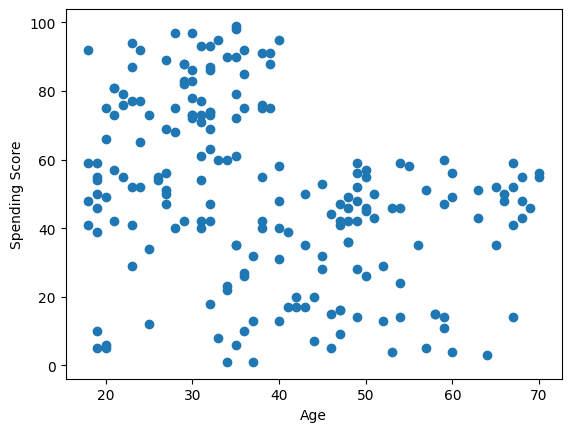

In [44]:
plt.scatter(df['Age'],df['Spending Score (1-100)'])   
plt.xlabel("Age")
plt.ylabel("Spending Score")

In [45]:
scaler = MinMaxScaler()
scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])
scaler.fit(df[['Spending Score (1-100)']])
df['Spending Score (1-100)'] = scaler.transform(df[['Spending Score (1-100)']])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,0.019231,15,0.387755
1,2,Male,0.057692,15,0.816327
2,3,Female,0.038462,16,0.051020
3,4,Female,0.096154,16,0.775510
4,5,Female,0.250000,17,0.397959


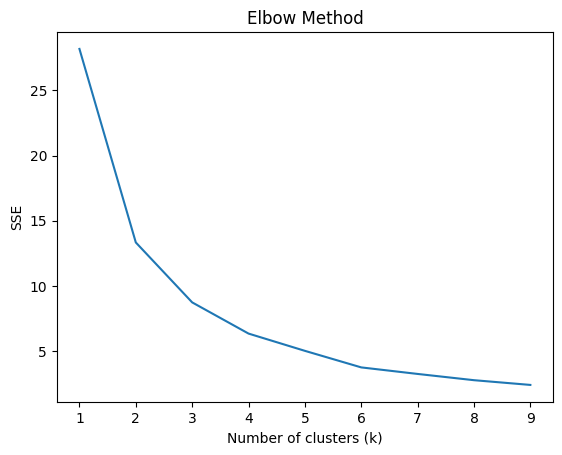

In [46]:
sse = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(df[['Age', 'Spending Score (1-100)']])
    sse.append(km.inertia_)

plt.plot(k_range, sse)
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

In [47]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,0.019231,15,0.387755
1,2,Male,0.057692,15,0.816327
2,3,Female,0.038462,16,0.051020
3,4,Female,0.096154,16,0.775510
4,5,Female,0.250000,17,0.397959


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6936\3214936138.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


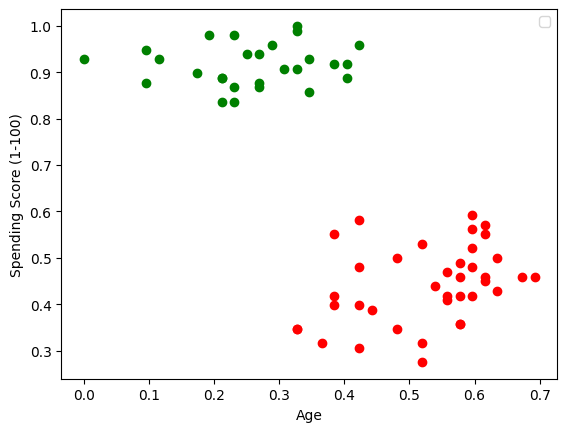

In [60]:
km = KMeans(n_clusters=7)
y_predicted = km.fit_predict(df[['Age','Spending Score (1-100)']])
df['cluster']= y_predicted 

df1= df[df.cluster==0]
df2= df[df.cluster==1]


plt.scatter(df1.Age, df1['Spending Score (1-100)' ] ,color= 'Green')
plt.scatter(df2.Age, df2['Spending Score (1-100)' ], color= "Red")


plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()